In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

latex_installed=True

plt.rcParams['pdf.fonttype'] = 42
plt.rc('text', usetex=latex_installed)
plt.rcParams['font.sans-serif'] = "Arial"
plt.rcParams['font.family'] = "sans-serif"

In [2]:
def create_plot(dataset, input_df, ax1, ax2, evaluation_metric, total_num_datapoints, y_labels=False):
    seeds = [int(seed) for seed in list(input_df.seed.unique())]
    test_scores = {}
    qty_removed = {}

    experiment_list = [
        'random', 
        'important_first_shapley', 'least_first_shapley', 
        'important_first_loo', 'least_first_loo',
        'remove_longest_sessions', 'remove_shortest_sessions'
    ]
    
    for exp in experiment_list:
        test_scores[exp] = []
        qty_removed[exp] = []

        for seed in seeds:
            exp_data = input_df[(input_df.seed == seed) & (input_df.exp == exp)].sort_values("qty_removed")
            if not exp_data.empty:
                test_scores[exp].append(exp_data.test_score.values)
                qty_removed[exp].append(exp_data.qty_removed.values)

    # Compute baseline (full-data) score
    if 'random' not in test_scores or len(test_scores['random']) == 0 or len(test_scores['random'][0]) == 0:
        raise ValueError("Missing or empty 'random' experiment — cannot compute baseline MRR.")
    test_score_fulldata = test_scores['random'][0][0]

    ax1.axhline(y=0, color='gray', linestyle='--')
    ax2.axhline(y=0, color='gray', linestyle='--')

    colors = {
        'important_first_shapley': 'green', 
        'least_first_shapley': 'green', 
        'important_first_loo': 'magenta', 
        'least_first_loo': 'magenta',    
        'random': 'black',
        'remove_longest_sessions': 'tab:blue',
        'remove_shortest_sessions': 'tab:blue',
    }

    labels = {
        'important_first_shapley': 'DSV', 
        'least_first_shapley': 'DSV', 
        'important_first_loo': 'LOO', 
        'least_first_loo': 'LOO',     
        'random': 'Random',
        'remove_longest_sessions': 'Heuristic',
        'remove_shortest_sessions': 'Heuristic',
    }

    metrics = { 'mrr@20': 'MRR@20', 'mrr@21': 'MRR@21' }

    for exp, ax in [
        ('important_first_shapley', ax1),
        ('important_first_loo', ax1),
        ('random', ax1),
        ('remove_shortest_sessions', ax1),
        ('least_first_shapley', ax2),
        ('least_first_loo', ax2),
        ('random', ax2),
        ('remove_longest_sessions', ax2)
    ]:
        if exp not in test_scores or len(test_scores[exp]) == 0:
            continue

        # Convert x-axis to percentage of sessions removed
        x_vals = [arr / total_num_datapoints * 100 for arr in qty_removed[exp]]
        min_len = min(len(x) for x in x_vals)

        # Truncate to the shortest available run
        x_vals = [x[:min_len] for x in x_vals]
        y_vals = [y[:min_len] for y in test_scores[exp]]

        x_plot = x_vals[0]
        initial_score = np.mean([y[0] for y in y_vals])
        means = np.mean(np.stack(y_vals), axis=0) - initial_score
        stddev = np.std(np.stack(y_vals), axis=0)

        ax.plot(x_plot, means, label=labels[exp], color=colors[exp])
        ax.fill_between(x_plot, means + stddev, means - stddev, alpha=0.25, color=colors[exp])

    ax1.set_title(dataset, fontsize=18)
    ax1.set_xlabel('Fraction of data removed (\%)', fontsize=14)
    ax2.set_xlabel('Fraction of data removed (\%)', fontsize=14)

    ax1.legend(ncol=2, columnspacing=0.7, handlelength=1, fontsize=11, loc='lower left')
    ax2.legend(ncol=2, columnspacing=0.7, handlelength=1, fontsize=11, loc='lower left')

    if y_labels:
        ax1.set_ylabel('Difference in\n' + metrics[evaluation_metric], fontsize=16)
        ax2.set_ylabel('Difference in\n' + metrics[evaluation_metric], fontsize=16)

    ax1.set_ylim((-0.065, 0.02))
    ax2.set_ylim((-0.015, 0.015))

FileNotFoundError: [Errno 2] No such file or directory: '24410/__removal_impact_results_importance_mrr@21_eval_mrr@21.csv'

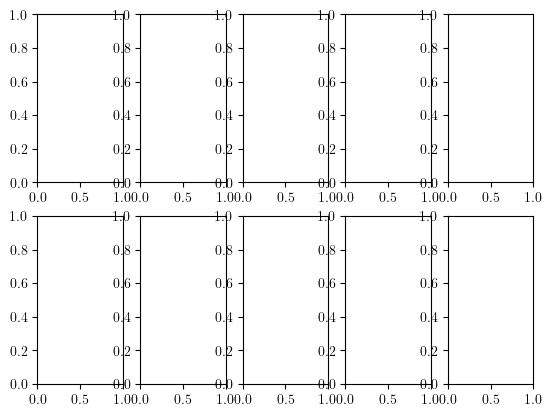

In [3]:
fig, ((ax1, ax2, ax3, ax4, ax5), (ax6, ax7, ax8, ax9, ax10)) = plt.subplots(2, 5)

output_name = '../figures/sbr_removal_impact.pdf'

df = pd.read_csv(os.path.join('24410/', '__removal_impact_results_importance_mrr@21_eval_mrr@21.csv'), 
                      header=None, index_col=None, names=['exp', 'seed', 'valid_score', 'test_score', 'qty_removed'])
df_length = pd.read_csv(os.path.join('24410/', 'session_length_removal_experiments.csv')).rename(columns={
    'experiment_name': 'exp',
    'valid_metric_score': 'valid_score',
    'test_metric_score': 'test_score',
    'num_sessions_removed': 'qty_removed'
})
df = pd.concat([df, df_length], ignore_index=True)
create_plot(r'\phantom{00}\textsc{x-literature}', df, ax1, ax6, 'mrr@20', 393656, y_labels=True)

df = pd.read_csv(os.path.join('11306/', '__removal_impact_results_importance_mrr@21_eval_mrr@21.csv'), 
                      header=None, index_col=None, names=['exp', 'seed', 'valid_score', 'test_score', 'qty_removed'])
df_length = pd.read_csv(os.path.join('11306/', 'session_length_removal_experiments.csv')).rename(columns={
    'experiment_name': 'exp',
    'valid_metric_score': 'valid_score',
    'test_metric_score': 'test_score',
    'num_sessions_removed': 'qty_removed'
})
df = pd.concat([df, df_length], ignore_index=True)
create_plot(r'\phantom{000}\textsc{x-babycare}', df, ax2, ax7, 'mrr@20', 29325)

df = pd.read_csv(os.path.join('36811/', '__removal_impact_results_importance_mrr@21_eval_mrr@21.csv'), 
                      header=None, index_col=None, names=['exp', 'seed', 'valid_score', 'test_score', 'qty_removed'])
df_length = pd.read_csv(os.path.join('36811/', 'session_length_removal_experiments.csv')).rename(columns={
    'experiment_name': 'exp',
    'valid_metric_score': 'valid_score',
    'test_metric_score': 'test_score',
    'num_sessions_removed': 'qty_removed'
})
df = pd.concat([df, df_length], ignore_index=True)
create_plot(r'\phantom{0}\textsc{x-woodentoys}', df, ax3, ax8, 'mrr@20', 98420)

df = pd.read_csv(os.path.join('nowplaying1m/', '__removal_impact_results_importance_mrr@20_eval_mrr@20.csv'), 
                      header=None, index_col=None, names=['exp', 'seed', 'valid_score', 'test_score', 'qty_removed'])
df_length = pd.read_csv(os.path.join('nowplaying1m/', 'session_length_removal_experiments.csv')).rename(columns={
    'experiment_name': 'exp',
    'valid_metric_score': 'valid_score',
    'test_metric_score': 'test_score',
    'num_sessions_removed': 'qty_removed'
})
df = pd.concat([df, df_length], ignore_index=True)
create_plot(r'\phantom{000}\textsc{nowplaying}', df, ax4, ax9, 'mrr@20', 97922)

df = pd.read_csv(os.path.join('instacart250k/', '__removal_impact_results_importance_mrr@20_eval_mrr@20.csv'), 
                      header=None, index_col=None, names=['exp', 'seed', 'valid_score', 'test_score', 'qty_removed'])
df_length = pd.read_csv(os.path.join('instacart250k/', 'session_length_removal_experiments.csv')).rename(columns={
    'experiment_name': 'exp',
    'valid_metric_score': 'valid_score',
    'test_metric_score': 'test_score',
    'num_sessions_removed': 'qty_removed'
})
df = pd.concat([df, df_length], ignore_index=True)
create_plot(r'\phantom{0000}\textsc{instacart}', df, ax5, ax10, 'mrr@20', 21068)

for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    ax.tick_params(axis='both', which='major', labelsize=14)
    
for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10]:
    ax.set_xlim((0, 25))
    ax.set_xticks([0, 5, 10, 15, 20, 25])
    ax.tick_params(axis='both', which='major', labelsize=14)

for ax in [ax2, ax3, ax4, ax5, ax7, ax8, ax9, ax10]:
    ax.set_yticks([])
    ax.set_yticks([], minor=True)

fig.set_figwidth(14)
fig.set_figheight(6)
plt.tight_layout()
plt.savefig(output_name, format='pdf', dpi=300)
plt.show()